In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
np.random.seed(42)

n = 300

voltage = np.random.normal(5.0, 0.5, n)
current = np.random.normal(0.25, 0.08, n)
temperature = np.random.normal(35, 8, n)
resistance = np.random.normal(20, 5, n)

fault = (
    (voltage < 4.3) |
    (voltage > 5.7) |
    (current > 0.40) |
    (temperature > 55) |
    (resistance < 10)
).astype(int)

data = pd.DataFrame({
    "Voltage": voltage,
    "Current": current,
    "Temperature": temperature,
    "Resistance": resistance,
    "Fault": fault
})

data.head()

,Voltage,Current,Temperature,Resistance,Fault
0,5.248357,0.183680,41.055909,21.843367,0
1,4.930868,0.205186,27.622677,18.033306,0
2,5.323844,0.309783,41.956847,20.143724,0
3,5.761515,0.298830,45.845103,26.392259,1
4,4.882923,0.248328,38.307479,20.955495,0


In [3]:
print("Dataset shape:", data.shape)
print("\nClass distribution:")
print(data["Fault"].value_counts())

print("\nDataset information:")
print(data.describe())

Dataset shape: (300, 5)

Class distribution:
Fault
0    233
1     67
Name: count, dtype: int64

Dataset information:
          Voltage     Current  Temperature  Resistance       Fault
count  300.000000  300.000000   300.000000  300.000000  300.000000
mean     4.997226    0.248281    35.657553   20.491866    0.223333
std      0.492097    0.076929     7.973412    5.049068    0.417176
min      3.379366    0.052268    13.424907    5.518723    0.000000
25%      4.658377    0.193648    30.428198   17.219349    0.000000
50%      5.029610    0.248499    35.341924   20.825783    0.000000
75%      5.313329    0.299307    40.691757   23.747112    0.000000
max      6.926366    0.496310    56.059057   32.198762    1.000000


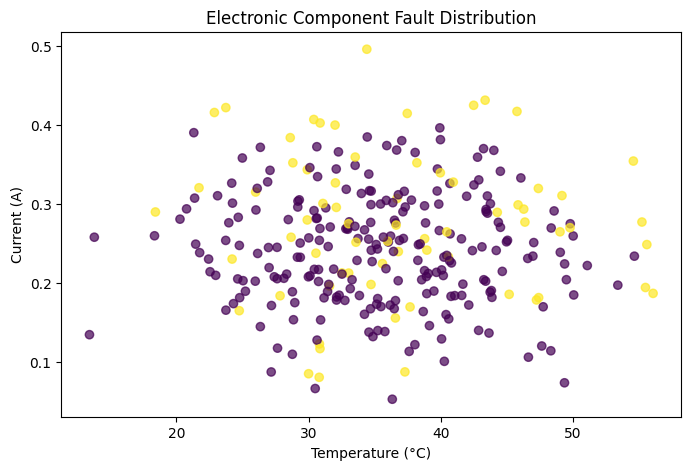

In [4]:
plt.figure(figsize=(8,5))

plt.scatter(
    data["Temperature"],
    data["Current"],
    c=data["Fault"],
    alpha=0.7
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Current (A)")
plt.title("Electronic Component Fault Distribution")
plt.show()

In [5]:
X = data[["Voltage", "Current", "Temperature", "Resistance"]]
y = data["Fault"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 240
Testing samples: 60


In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [7]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        47
           1       0.87      1.00      0.93        13

    accuracy                           0.97        60
   macro avg       0.93      0.98      0.95        60
weighted avg       0.97      0.97      0.97        60



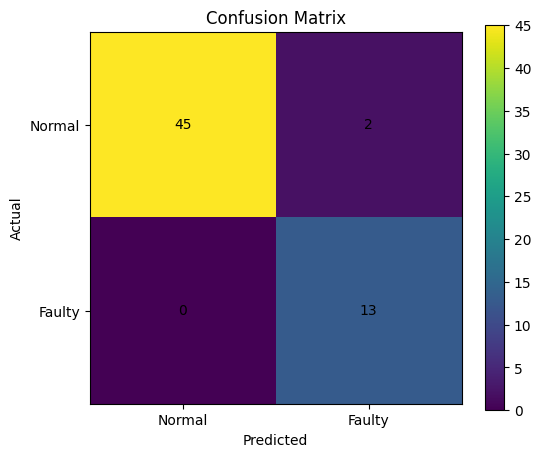

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Normal", "Faulty"])
plt.yticks([0, 1], ["Normal", "Faulty"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [9]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Voltage        0.645833
Resistance     0.146279
Current        0.129359
Temperature    0.078530
dtype: float64


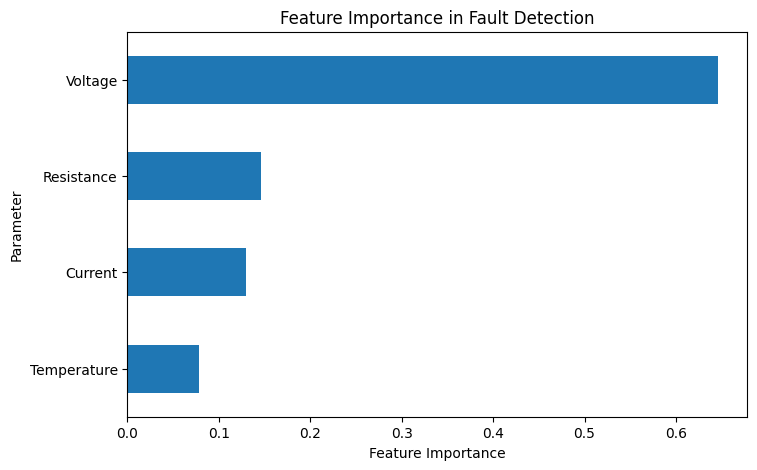

In [10]:
plt.figure(figsize=(8, 5))

importance.sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Parameter")
plt.title("Feature Importance in Fault Detection")

plt.show()

In [11]:
new_component = pd.DataFrame({
    "Voltage": [5.0],
    "Current": [0.22],
    "Temperature": [35],
    "Resistance": [20]
})

prediction = model.predict(new_component)

if prediction[0] == 0:
    print("Prediction: NORMAL ✅")
else:
    print("Prediction: FAULTY ⚠️")

Prediction: NORMAL ✅


In [12]:
faulty_component = pd.DataFrame({
    "Voltage": [4.0],
    "Current": [0.45],
    "Temperature": [65],
    "Resistance": [8]
})

prediction = model.predict(faulty_component)

if prediction[0] == 0:
    print("Prediction: NORMAL ✅")
else:
    print("Prediction: FAULTY ⚠️")

Prediction: FAULTY ⚠️
